In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [123]:
data = pd.read_csv("C:\\Users\\User\\Desktop\\дані для диплому\\mfvar1_dataset.csv")
data

,Показник,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log,conf_ind_build_log,conf_ind_service_log,kyiv_gdp_log
0,2010-01-31,0.008880,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-02-28,0.000982,NaN,NaN,NaN,NaN,NaN,0.009872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-03-31,-0.009862,NaN,NaN,NaN,NaN,NaN,-0.005911,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-04-30,-0.011964,NaN,NaN,NaN,NaN,NaN,0.001974,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-05-31,-0.003014,NaN,NaN,NaN,NaN,NaN,0.004919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,2025-08-31,0.000000,NaN,NaN,NaN,NaN,NaN,-0.004973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
188,2025-09-30,0.004998,NaN,-0.027514,0.058380,NaN,NaN,-0.001996,-0.035367,0.432566,0.418511,NaN,0.082013,0.049663,NaN
189,2025-10-31,0.005964,NaN,NaN,NaN,NaN,NaN,0.000999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,2025-11-30,-0.004968,NaN,NaN,NaN,NaN,NaN,0.004978,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [124]:
data["Показник"] = pd.to_datetime(data["Показник"])

In [125]:
season_dummy = pd.get_dummies(data["Показник"].dt.month, prefix='M',drop_first=True).astype(float)
season_dummy

,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,M_11,M_12
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
187,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
188,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
190,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [126]:
data = data.set_index("Показник")

In [127]:
season_dummy["Показник"] = data.index

In [128]:
season_dummy = season_dummy.set_index("Показник")

In [129]:
data.head()

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log,conf_ind_build_log,conf_ind_service_log,kyiv_gdp_log
Показник,,,,,,,,,,,,,,
2010-01-31,0.008880,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,0.000982,NaN,NaN,NaN,NaN,NaN,0.009872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,-0.009862,NaN,NaN,NaN,NaN,NaN,-0.005911,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,-0.011964,NaN,NaN,NaN,NaN,NaN,0.001974,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-05-31,-0.003014,NaN,NaN,NaN,NaN,NaN,0.004919,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
train_end = '2020-03-31'
train_endog = data.loc[:train_end]
train_exog = season_dummy.loc[:train_end]

In [131]:
train_endog

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log,conf_ind_build_log,conf_ind_service_log,kyiv_gdp_log
Показник,,,,,,,,,,,,,,
2010-01-31,0.008880,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-28,0.000982,NaN,NaN,NaN,NaN,NaN,0.009872,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-03-31,-0.009862,NaN,NaN,NaN,NaN,NaN,-0.005911,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-04-30,-0.011964,NaN,NaN,NaN,NaN,NaN,0.001974,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-05-31,-0.003014,NaN,NaN,NaN,NaN,NaN,0.004919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-30,-0.005976,NaN,NaN,NaN,NaN,NaN,0.006030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31,-0.003002,0.000727,-0.023397,-0.056750,-0.002954,-0.002857,-0.006030,0.025617,0.433031,0.354006,-0.022835,-0.099239,-0.005314,0.098475
2020-01-31,0.004000,NaN,NaN,NaN,NaN,NaN,0.035647,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [132]:
train_exog

,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,M_11,M_12
Показник,,,,,,,,,,,
2010-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-02-28,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-03-31,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-04-30,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010-05-31,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2019-11-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2019-12-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2020-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [79]:
train_endog_m = train_endog[["infl_ukr_log", "constr_ind_log"]]

In [80]:
train_endog_q = train_endog[["gdp_ua_log", "export_log", "import_log", "empl_ua_log", "empl_kyiv_log", "house_ind_log", "house_space_kyiv_log", "house_space_ua_log"]]

In [133]:
model = sm.tsa.DynamicFactorMQ(
    endog=train_endog,
    factors=['gdp_ua_log', 'infl_ukr_log'],
    factor_order=4,
    quarterly=['gdp_ua_log', 'export_log', 'import_log', 'empl_ua_log', 'empl_kyiv_log', 'house_ind_log', 'house_space_kyiv_log', 'house_space_ua_log', 'conf_ind_finance_log', 'conf_ind_build_log', 'conf_ind_service_log'],
    annual=['kyiv_gdp_log']
)

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency M will be used.
  self._init_dates(dates, freq)
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['factor_order', 'quarterly', 'annual']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [134]:
results = model.fit(disp=True)

EM start iterations, llf=-613.4
EM iteration 2, llf=-597.01, convergence criterion=0.027079
EM iteration 3, llf=-588.83, convergence criterion=0.013795
EM iteration 4, llf=-583.76, convergence criterion=0.0086461
EM iteration 5, llf=-580.42, convergence criterion=0.0057364
EM iteration 6, llf=-578.11, convergence criterion=0.0039917
EM iteration 7, llf=-576.43, convergence criterion=0.0028992
EM iteration 8, llf=-575.17, convergence criterion=0.0021904
EM iteration 9, llf=-574.19, convergence criterion=0.0017158
EM iteration 10, llf=-573.39, convergence criterion=0.0013889
EM iteration 11, llf=-572.73, convergence criterion=0.0011576
EM iteration 12, llf=-572.16, convergence criterion=0.0009898
EM iteration 13, llf=-571.66, convergence criterion=0.00086507
EM iteration 14, llf=-571.22, convergence criterion=0.00077014
EM iteration 15, llf=-570.83, convergence criterion=0.00069621
EM iteration 16, llf=-570.46, convergence criterion=0.00063733
EM iteration 17, llf=-570.13, convergence cr

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\dynamic_factor_mq.py:2691: UserWarning: EM reached maximum number of iterations (500), without achieving convergence: llf=-548.09, convergence criterion=3.8452e-06 (while specified tolerance was 1e-06)
  warn(f'EM reached maximum number of iterations ({maxiter}),'


In [135]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         Model Specification: Dynamic Factor Model                         
===========================================================================================
Model:                Dynamic Factor Model   # of observed variables:                    14
                   + 2 factors in 2 blocks   # of factor blocks:                          2
                     + AR(1) idiosyncratic   Idiosyncratic disturbances:              AR(1)
Sample:                2010-01-31 00:00:00   Standardize variables:                    True
                     - 2020-03-31 00:00:00                                                 
    Observed variables / factor loadings    
============================================
       Dep. variable gdp_ua_log infl_ukr_log
--------------------------------------------
        infl_ukr_log     X           X      
          gdp_ua_log     X           X      
          export_log     X           X      
          import_log     X           X      
         empl_ua_log     X           X      
       empl_kyiv_log     X           X      
      constr_ind_log     X           X      
       house_ind_log     X           X      
house_space_kyiv_log     X           X      
  house_space_ua_log     X           X      
conf_ind_finance_log     X           X      
  conf_ind_build_log     X           X      
conf_ind_service_log     X           X      
        kyiv_gdp_log     X           X      
     Factor blocks:    
=======================
       block      order
-----------------------
  gdp_ua_log          1
infl_ukr_log          1
=======================
"""

In [136]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 Dynamic Factor Results                                
=======================================================================================
Dep. Variable:     "infl_ukr_log", and 13 more   No. Observations:                  123
Model:                    Dynamic Factor Model   Log Likelihood                -548.085
                       + 2 factors in 2 blocks   AIC                           1216.170
                         + AR(1) idiosyncratic   BIC                           1384.901
Date:                         Fri, 01 May 2026   HQIC                          1284.709
Time:                                 08:42:43   EM Iterations                      500
Sample:                             01-31-2010                                         
                                  - 03-31-2020                                         
Covariance Type:                  Not computed                                         
                             Observation equation:                              
================================================================================
    Factor loadings: gdp_ua_log infl_ukr_log    idiosyncratic: AR(1)        var.
--------------------------------------------------------------------------------
        infl_ukr_log      -0.01        -0.01                   -0.06        0.98
          gdp_ua_log       0.14         0.17                    0.82        0.05
          export_log       0.08         0.16                   -0.58        0.31
          import_log       0.06         0.21                   -0.70        0.11
         empl_ua_log       0.08         0.03                    0.66        0.47
       empl_kyiv_log      -0.06        -0.10                    0.38        0.58
      constr_ind_log       0.01         0.03                   -0.43        0.80
       house_ind_log      -0.02         0.07                   -0.67        0.49
house_space_kyiv_log      -0.02         0.20                    0.35        0.00
  house_space_ua_log      -0.02         0.21                    0.71        0.01
conf_ind_finance_log       0.15        -0.09                    0.00        0.01
  conf_ind_build_log      -0.01         0.04                    0.70        0.50
conf_ind_service_log       0.12        -0.03                    0.03        0.37
        kyiv_gdp_log       0.01         0.17                   -0.00        0.57
        Transition: Factor block 0        
==========================================
           L1.gdp_ua_log    error variance
------------------------------------------
gdp_ua_log          0.70             16.99
          Transition: Factor block 1          
==============================================
             L1.infl_ukr_log    error variance
----------------------------------------------
infl_ukr_log           -0.61             12.41
==============================================

Warnings:
[1] Covariance matrix not calculated.
"""

In [137]:
rsquared = results.get_coefficients_of_determination(method='individual')

In [138]:
rsquared

,gdp_ua_log,infl_ukr_log
infl_ukr_log,0.031830,0.006996
gdp_ua_log,0.307867,0.443202
export_log,0.199027,0.452089
import_log,0.063011,0.678824
empl_ua_log,0.118931,0.026387
empl_kyiv_log,0.131075,0.129018
constr_ind_log,0.001205,0.064620
house_ind_log,0.021244,0.072640
house_space_kyiv_log,0.099720,0.997528
house_space_ua_log,0.136512,0.989354


In [139]:
forecast_exog = season_dummy['2022-01-31':'2022-12-31']

In [140]:
forecast_exog

,M_2,M_3,M_4,M_5,M_6,M_7,M_8,M_9,M_10,M_11,M_12
Показник,,,,,,,,,,,
2022-01-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-02-28,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-03-31,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-04-30,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-05-31,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-06-30,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2022-07-31,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2022-08-31,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2022-09-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [220]:
point_forecasts = results.forecast(steps=12)

In [221]:
points_forecast_q = point_forecasts["gdp_ua_log"].resample('Q').last()
points_forecast_q

2020-06-30    0.101629
2020-09-30    0.035279
2020-12-31    0.051307
2021-03-31    0.045135
Freq: Q-DEC, Name: gdp_ua_log, dtype: float64

In [232]:
nowcast_gdp = nowcast_df["gdp_ua_log"]['2012-01-31':].resample('Q').last()
nowcast_gdp

2012-03-31    0.018948
2012-06-30    0.050546
2012-09-30    0.016764
2012-12-31    0.025628
2013-03-31    0.026881
2013-06-30    0.023679
2013-09-30    0.014732
2013-12-31    0.032209
2014-03-31    0.075282
2014-06-30    0.029469
2014-09-30    0.043581
2014-12-31    0.038969
2015-03-31    0.044781
2015-06-30    0.029462
2015-09-30    0.230911
2015-12-31    0.055092
2016-03-31    0.041404
2016-06-30   -0.026472
2016-09-30    0.081185
2016-12-31    0.019913
2017-03-31   -0.027902
2017-06-30   -0.049621
2017-09-30    0.067161
2017-12-31    0.054276
2018-03-31   -0.011480
2018-06-30    0.019565
2018-09-30    0.041109
2018-12-31    0.069324
2019-03-31    0.019954
2019-06-30    0.070814
2019-09-30    0.029049
2019-12-31    0.066079
2020-03-31    0.027430
Freq: Q-DEC, Name: gdp_ua_log, dtype: float64

In [222]:
res_nowcast = results.get_prediction(start=train_endog.index[0], end=train_endog.index[-1])

In [223]:
nowcast_df = res_nowcast.predicted_mean

In [224]:
nowcast_df

,infl_ukr_log,gdp_ua_log,export_log,import_log,empl_ua_log,empl_kyiv_log,constr_ind_log,house_ind_log,house_space_kyiv_log,house_space_ua_log,conf_ind_finance_log,conf_ind_build_log,conf_ind_service_log,kyiv_gdp_log
2010-01-31,0.008880,0.437843,0.115070,0.142080,0.013511,-0.004681,4.003417e-17,-0.002933,0.244113,0.152833,0.215509,0.024427,0.145259,0.224540
2010-02-28,-0.001679,0.230094,0.055054,0.046424,0.009576,-0.000765,1.462864e-03,-0.006952,-0.389942,-0.476349,0.190494,0.014068,0.119499,0.165791
2010-03-31,-0.000987,0.224213,0.063681,0.073547,0.007943,-0.001014,-3.005188e-03,-0.002167,0.067376,0.005419,0.138886,0.024522,0.093770,0.194483
2010-04-30,0.000008,0.141561,0.040974,0.038871,0.006205,0.000503,3.232713e-03,-0.003211,-0.131024,-0.188287,0.123165,0.021618,0.080689,0.174550
2010-05-31,0.000253,0.130733,0.041941,0.045716,0.005396,0.000565,-2.988983e-04,-0.001478,0.024415,-0.022953,0.101675,0.025340,0.069432,0.183527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-11-30,0.000058,0.120910,0.014561,0.033942,0.005312,0.002031,5.412109e-03,-0.012336,0.252606,0.183845,0.039393,0.000398,0.033308,0.190485
2019-12-31,0.000491,0.066079,0.019314,0.007128,0.004154,0.002820,-2.947622e-03,0.008503,-0.083733,-0.147473,0.056941,0.003158,0.039282,0.165493
2020-01-31,0.000781,-0.036369,0.009813,0.034072,-0.001595,0.001823,1.544385e-03,-0.013835,-0.063934,-0.130530,0.014892,-0.068380,0.012733,0.158343
2020-02-29,0.000100,0.018815,-0.000984,-0.027249,0.000061,0.002110,-1.594629e-02,0.010607,0.105575,0.054521,0.025056,-0.036824,0.021909,0.175142


In [230]:
gdp_actual = train_endog['gdp_ua_log'].dropna()
gdp_test = data["gdp_ua_log"]['2020-04-30':'2021-03-31'].dropna()

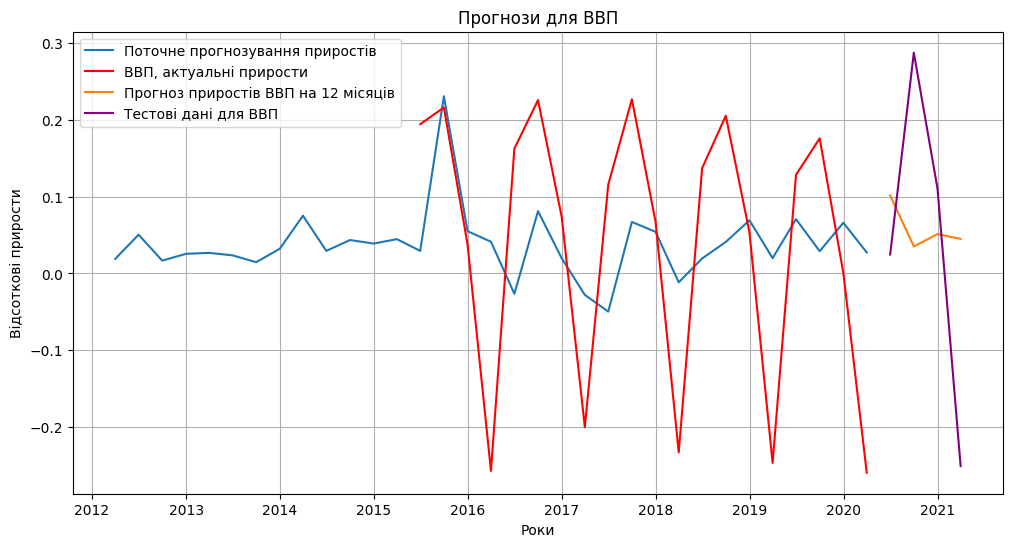

In [233]:
plt.figure(figsize=(12, 6))
plt.title("Прогнози для ВВП")
plt.ylabel("Відсоткові прирости")
plt.xlabel("Роки")
plt.plot(nowcast_gdp, label='Поточне прогнозування приростів')
plt.plot(gdp_actual.index, gdp_actual, color='red', label='ВВП, актуальні прирости')
plt.plot(points_forecast_q, label='Прогноз приростів ВВП на 12 місяців')
plt.plot(gdp_test.index, gdp_test, color='purple', label='Тестові дані для ВВП')
plt.grid(True)
plt.legend()
plt.show()

In [175]:
data["gdp_ua_log"]['2020-04-30':'2021-03-31']

Показник
2020-04-30         NaN
2020-05-31         NaN
2020-06-30    0.024744
2020-07-31         NaN
2020-08-31         NaN
2020-09-30    0.287584
2020-10-31         NaN
2020-11-30         NaN
2020-12-31    0.110807
2021-01-31         NaN
2021-02-28         NaN
2021-03-31   -0.250944
Name: gdp_ua_log, dtype: float64

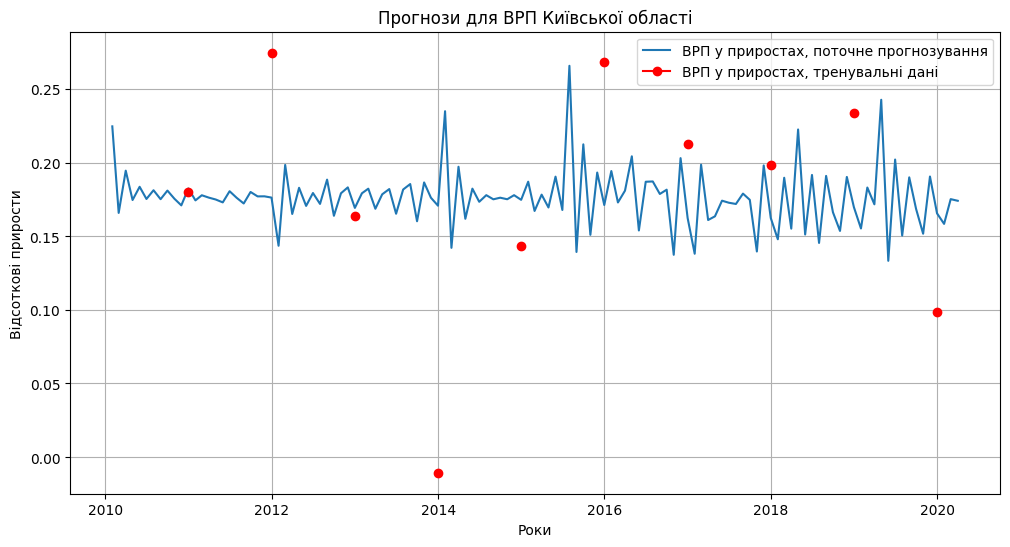

In [188]:
plt.figure(figsize=(12, 6))
plt.title("Прогнози для ВРП Київської області")
plt.ylabel("Відсоткові прирости")
plt.xlabel("Роки")
plt.plot(nowcast_df["kyiv_gdp_log"], label='ВРП у приростах, поточне прогнозування')
plt.plot(train_endog.index, train_endog['kyiv_gdp_log'], marker='o', color='red', label='ВРП у приростах, тренувальні дані')
plt.legend()
plt.grid(True)
plt.show()

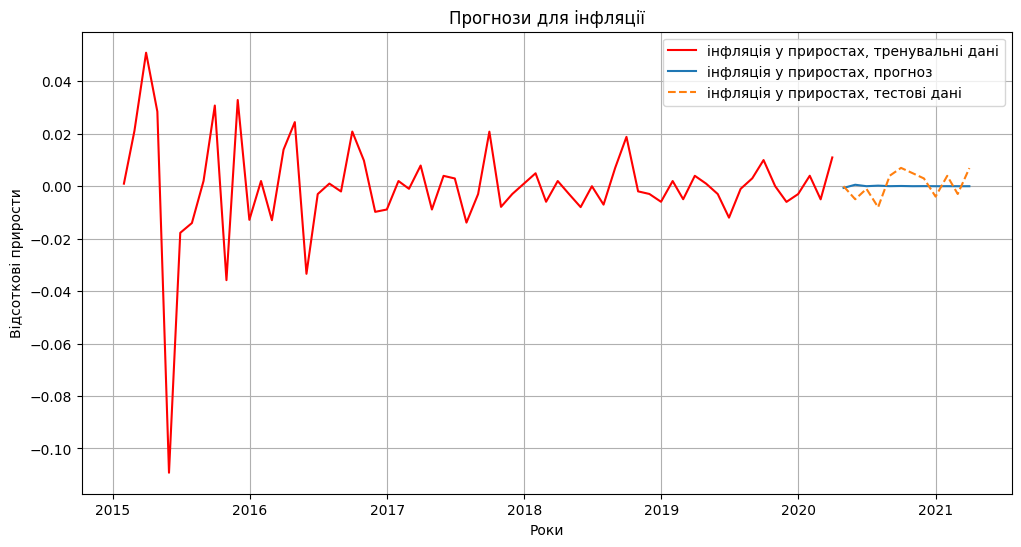

In [184]:
plt.figure(figsize=(12, 6))
plt.title("Прогнози для інфляції")
plt.ylabel("Відсоткові прирости")
plt.xlabel("Роки")
plt.plot(train_endog['infl_ukr_log']['2015-01-31':], color='red', label='інфляція у приростах, тренувальні дані')
plt.plot(point_forecasts["infl_ukr_log"], label='інфляція у приростах, прогноз')
plt.plot(data["infl_ukr_log"]['2020-04-30':'2021-03-31'], linestyle='--', label='інфляція у приростах, тестові дані')
plt.legend()
plt.grid(True)
plt.show()

In [151]:
nowcast_df['gdp_ua_log']

2010-01-31    0.437843
2010-02-28    0.230094
2010-03-31    0.224213
2010-04-30    0.141561
2010-05-31    0.130733
                ...   
2019-11-30    0.120910
2019-12-31    0.066079
2020-01-31   -0.036369
2020-02-29    0.018815
2020-03-31    0.027430
Freq: M, Name: gdp_ua_log, Length: 123, dtype: float64

In [152]:
train_endog["gdp_ua_log"].tail(10)

Показник
2019-06-30    0.128514
2019-07-31         NaN
2019-08-31         NaN
2019-09-30    0.176056
2019-10-31         NaN
2019-11-30         NaN
2019-12-31    0.000727
2020-01-31         NaN
2020-02-29         NaN
2020-03-31   -0.259521
Name: gdp_ua_log, dtype: float64

In [202]:
q_predict = point_forecasts["gdp_ua_log"].resample('Q').mean()

In [203]:
q_predict

2020-06-30    0.072798
2020-09-30    0.038435
2020-12-31    0.050841
2021-03-31    0.046117
Freq: Q-DEC, Name: gdp_ua_log, dtype: float64

In [204]:
test_data = data["gdp_ua_log"]['2020-06-30':'2021-03-31']

In [205]:
test_data.dropna(inplace=True)

In [206]:
test_data

Показник
2020-06-30    0.024744
2020-09-30    0.287584
2020-12-31    0.110807
2021-03-31   -0.250944
Name: gdp_ua_log, dtype: float64

In [207]:
from sklearn.metrics import mean_squared_error

In [208]:
rmse = np.sqrt(mean_squared_error(test_data, q_predict))

In [209]:
rmse

0.19762687379102958

In [210]:
mae = np.mean(abs(test_data - q_predict))
mae

0.16355742795302086

In [211]:
q_predict = point_forecasts["infl_ukr_log"]

In [212]:
test_data = data["infl_ukr_log"]['2020-04-30':'2021-03-31']

In [213]:
test_data

Показник
2020-04-30    0.000000
2020-05-31   -0.004973
2020-06-30   -0.000998
2020-07-31   -0.008016
2020-08-31    0.004016
2020-09-30    0.006990
2020-10-31    0.004963
2020-11-30    0.002966
2020-12-31   -0.003956
2021-01-31    0.003956
2021-02-28   -0.002966
2021-03-31    0.006907
Name: infl_ukr_log, dtype: float64

In [214]:
test_data.dropna(inplace=True)

In [215]:
rmse = np.sqrt(mean_squared_error(test_data, q_predict))
rmse

0.004866971212769093

In [216]:
mae = np.mean(abs(test_data - q_predict))
mae

0.004331424803098415